# Sprinkler method functions to simplify code

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from src.analysis.stable_islands import outer_boundary_spline_from_interior_point
from src.integrator.integrate import FastSitnikovSimulation
from src.utils.boundary import B1_v_func

In [17]:
E = 0.5
SEED = 20260406

# Escape boundary B1 for reference plotting
theta_ref = np.linspace(0.0, 2.0 * np.pi, 361)
outer_boundary_func = B1_v_func(E, dv=2e-3, N_t=80)
v_outer_boundary = outer_boundary_func(theta_ref)

# Main central stable-island boundary approximation
_, main_spline = outer_boundary_spline_from_interior_point(
    e=E,
    p0=(0.25, 0.10),
    n_samples=80,
    positive_v_search=True,
    expected_dist=2.0,
    max_crossings=80,
    dist_error=1e-2,
    max_iterations=12,
    n_starts=8,
    max_passes=16,
    spline_degree=3,
    smoothing=1e-2,
    n_eval=400,
)

u_vals = np.linspace(0.0, 1.0, 300)
_points = main_spline(u_vals)

main_island_boundary = {
    'v': _points[0],
    't': np.mod(_points[1], 2.0 * np.pi),
    'spline': main_spline,
}

# Secondary stable-island boundary approximation
_, secondary_spline = outer_boundary_spline_from_interior_point(
    e=E,
    p0=(1.321, np.pi),
    n_samples=500,
    positive_v_search=True,
    expected_dist=2.0,
    max_crossings=80,
    dist_error=1e-2,
    max_iterations=12,
    n_starts=8,
    max_passes=16,
    spline_degree=3,
    smoothing=1e-2,
    n_eval=400,
)

u_vals_secondary = np.linspace(0.0, 1.0, 300)
_secondary_points = secondary_spline(u_vals_secondary)

# Keep traversal order from spline parameterization; do not sort by t
secondary_island_boundary = {
    'v': _secondary_points[0],
    't': np.mod(_secondary_points[1], 2.0 * np.pi),
    'spline': secondary_spline,
}

Visual check that the boundaries have been computed properly

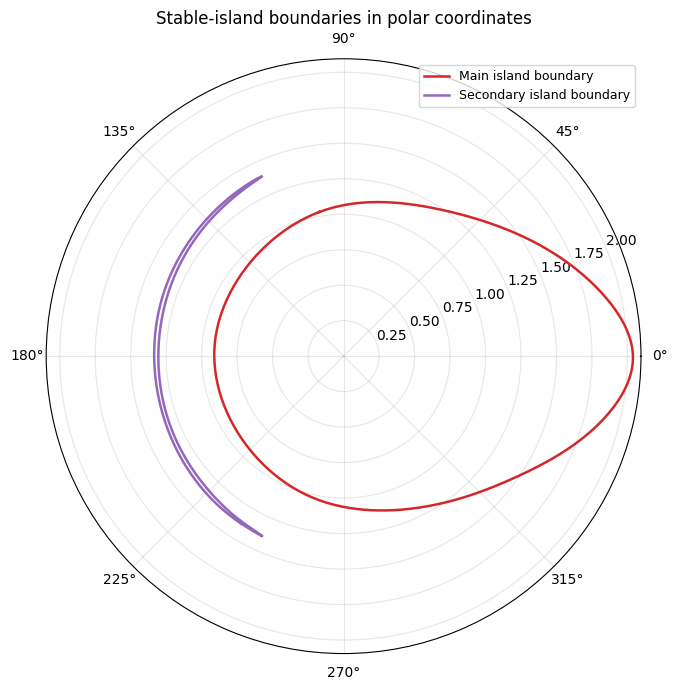

In [18]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})

ax.plot(
    main_island_boundary["t"],
    main_island_boundary["v"],
    color="tab:red",
    linewidth=1.8,
    label="Main island boundary",
)
ax.plot(
    secondary_island_boundary["t"],
    secondary_island_boundary["v"],
    color="tab:purple",
    linewidth=1.8,
    label="Secondary island boundary",
)

ax.set_title("Stable-island boundaries in polar coordinates")
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## Declaring the useful functions

In [36]:
def sprinkler(t_val, v_range, N0, N_STEPS, *, e=E, seed=SEED, rtol = 1e-7, atol = 1e-10):
    """
    Run a basic sprinkler experiment on the ray t=t_val with v in (v_range[0], v_range[1]).
    Returns start, middle and final survivor point clouds as dictionaries with keys 't' and 'v'.
    """
    v_lo, v_hi = float(v_range[0]), float(v_range[1])
    if v_lo <= 0.0 or v_hi <= 0.0 or v_lo >= v_hi:
        raise ValueError(f'Invalid v_range={v_range}. Expected 0 < v_min < v_max.')

    rng = np.random.default_rng(seed)
    sim = FastSitnikovSimulation(e=e, solver_method='RK45', rtol=rtol, atol=atol)
    t0_mod = float(np.mod(t_val, 2.0 * np.pi))
    mid_step = int(N_STEPS // 2)

    v0_samples = rng.uniform(v_lo, v_hi, size=int(N0))

    start_t = []
    start_v = []
    mid_t = []
    mid_v = []
    final_t = []
    final_v = []

    for v_init in v0_samples:
        t_curr = t0_mod
        v_curr = float(v_init)
        mid_state = None
        survived = True

        for step in range(1, int(N_STEPS) + 1):
            v_next, t_next = sim.phi_fast(v=v_curr, t=t_curr, return_mod_period=True)
            if v_next is None:
                survived = False
                break

            v_curr = float(v_next)
            t_curr = float(t_next)

            if step == mid_step:
                mid_state = (t_curr, v_curr)

        if survived:
            start_t.append(t0_mod)
            start_v.append(float(v_init))
            if mid_state is None:
                raise RuntimeError('Missing midpoint state for a surviving trajectory.')
            mid_t.append(mid_state[0])
            mid_v.append(mid_state[1])
            final_t.append(t_curr)
            final_v.append(v_curr)

    starting_points = {'t': np.array(start_t), 'v': np.array(start_v)}
    middle_points = {'t': np.array(mid_t), 'v': np.array(mid_v)}
    final_points = {'t': np.array(final_t), 'v': np.array(final_v)}

    return starting_points, middle_points, final_points

In [33]:
def plot_sprinkler_points(points, stage='start', *, rlim=(0.0, 3.0), show_boundaries=True):
    """
    Plot one sprinkler point cloud on the polar (t, v) section.
    stage: 'start', 'middle', 'final' (controls color/title).
    """
    style = {
        'start': ('tab:blue', 'Starting survivors'),
        'middle': ('tab:orange', 'Middle survivors'),
        'final': ('tab:green', 'Final survivors'),
    }
    if stage not in style:
        raise ValueError("stage must be one of: 'start', 'middle', 'final'")
    if not isinstance(points, dict) or 't' not in points or 'v' not in points:
        raise ValueError("points must be a dictionary with keys 't' and 'v'")

    color, title = style[stage]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    ax.scatter(points['t'], points['v'], s=10, alpha=0.7, color=color, label=title)

    if show_boundaries:
        ax.plot(theta_ref, v_outer_boundary, color='black', linewidth=1.4, alpha=0.9, label='Outer boundary (B1)')
        ax.plot(
            main_island_boundary['t'],
            main_island_boundary['v'],
            color='tab:red',
            linewidth=1.4,
            alpha=0.9,
            label='Main central-island boundary',
        )
        ax.plot(
            secondary_island_boundary['t'],
            secondary_island_boundary['v'],
            color='tab:purple',
            linewidth=1.4,
            alpha=0.9,
            label='Secondary-island boundary',
        )

    ax.set_title(title)
    ax.set_rlim(*rlim)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig, ax

In [ ]:
def plot_phi_iterates(
    v0,
    t0,
    n_steps,
    *,
    e=E,
    rtol=1e-7,
    atol=1e-9,
    show_boundaries=True,
    draw_lines=False,
):
    """
    Plot up to n_steps iterates of phi starting from (v0, t0) on the polar (t, v) section.
    Stops early if the trajectory escapes.
    draw_lines: if True, connect iterates with line segments.
    """
    sim = FastSitnikovSimulation(e=e, solver_method="RK45", rtol=rtol, atol=atol)

    t_vals = [float(np.mod(t0, 2.0 * np.pi))]
    v_vals = [float(v0)]

    for _ in range(int(n_steps)):
        v_next, t_next = sim.phi_fast(v=v_vals[-1], t=t_vals[-1], return_mod_period=True)
        if v_next is None:
            break
        v_vals.append(float(v_next))
        t_vals.append(float(t_next))

    t_vals = np.array(t_vals)
    v_vals = np.array(v_vals)
    survived_steps = len(v_vals) - 1
    escaped = survived_steps < int(n_steps)

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})

    if show_boundaries:
        ax.plot(theta_ref, v_outer_boundary, color="black", linewidth=1.2, alpha=0.8, label="Outer boundary (B1)")
        ax.plot(main_island_boundary["t"], main_island_boundary["v"], color="tab:red", linewidth=1.2, alpha=0.8, label="Main island")
        ax.plot(secondary_island_boundary["t"], secondary_island_boundary["v"], color="tab:purple", linewidth=1.2, alpha=0.8, label="Secondary island")

    if draw_lines:
        ax.plot(t_vals, v_vals, color="tab:blue", linewidth=1.4, alpha=0.9, label="Orbit path")

    sc = ax.scatter(t_vals, v_vals, c=np.arange(len(v_vals)), s=20, cmap="viridis", zorder=3, label="Iterates")
    fig.colorbar(sc, ax=ax, pad=0.1, label="Iteration index")

    ax.set_title(
        f"Iterates of $\\phi$ from (t0={t_vals[0]:.3f}, v0={v_vals[0]:.3f})\n"
        f"computed={survived_steps}/{int(n_steps)}{' (escaped)' if escaped else ''}"
    )
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    fig.tight_layout()
    plt.show()

    return fig, ax

## Declare the sprinkler region

In [ ]:
# We choose the range from which the sprinkler method starts
t_val = np.pi  # choose the ray angle (radians)
eps = 0.2      # shorten interval length by 20% while keeping center

def ray_intersections_from_spline(spline, t_ray, n_grid=4000):
    """Return intersection candidates (u, v) of spline with the ray t=t_ray."""
    u_grid = np.linspace(0.0, 1.0, n_grid)
    _points = spline(u_grid)
    v_grid, t_grid = _points[0], _points[1]
    t_grid = np.mod(t_grid, 2.0 * np.pi)

    ang_diff = np.angle(np.exp(1j * (t_grid - t_ray)))
    cross_idx = np.where(
        (ang_diff[:-1] * ang_diff[1:] <= 0.0) &
        (np.abs(ang_diff[1:] - ang_diff[:-1]) < np.pi)
)[0]

    if cross_idx.size == 0:
        raise RuntimeError('No intersections found for the selected ray.')

    u_candidates = []
    v_candidates = []
    for i in cross_idx:
        u0, u1 = u_grid[i], u_grid[i + 1]
        a0, a1 = ang_diff[i], ang_diff[i + 1]
        v0, v1 = v_grid[i], v_grid[i + 1]

        # Linear interpolation to ang_diff(u)=0 within the crossing segment
        if np.isclose(a1, a0):
            w = 0.0
        else:
            w = -a0 / (a1 - a0)

        u_star = float(u0 + w * (u1 - u0))
        v_star = float(v0 + w * (v1 - v0))
        u_candidates.append(u_star)
        v_candidates.append(v_star)

    return np.array(u_candidates), np.array(v_candidates)

# Intersections for main island, there should be one
u_main, v_main_candidates = ray_intersections_from_spline(main_island_boundary['spline'], t_val)
if v_main_candidates.size < 1:
    raise RuntimeError(f'Expected at least 1 main-island intersection, found {v_main_candidates.size}.')
v_main_lower = float(np.min(v_main_candidates))
v_main_upper = float(np.max(v_main_candidates))
print(v_main_upper)

# Intersections for secondary island, there should be two
u_secondary, v_secondary_candidates = ray_intersections_from_spline(secondary_island_boundary['spline'], t_val)
if v_secondary_candidates.size < 2:
    raise RuntimeError(f'Expected at least 2 secondary-island intersections, found {v_secondary_candidates.size}.')
v_secondary_lower = float(np.min(v_secondary_candidates))
v_secondary_upper = float(np.max(v_secondary_candidates))

# Use the pair that defines the gap between islands along this ray
v_main = v_main_upper
v_secondary = v_secondary_lower

if not (v_main < v_secondary):
    raise RuntimeError(
        f'Unexpected ordering: v_main={v_main:.6f} is not < v_secondary={v_secondary:.6f}. '
        'Check island seeds/splines or ray angle.'
    )

# Build interval from (v_main, v_secondary), then shorten by eps at same center
v_range = (1.1, 1.2) # hard-coded range

print(f't_val = {t_val:.6f}, eps = {eps:.3f}')
print('Main-island intersections (v):')
print(f'  lower = {v_main_lower:.6f}, upper = {v_main_upper:.6f}')
print('Secondary-island intersections (v):')
print(f'  lower = {v_secondary_lower:.6f}, upper = {v_secondary_upper:.6f}')
print('Chosen pair for interval:')
print(f'  v_main = {v_main:.6f} (main island)')
print(f'  v_secondary = {v_secondary:.6f} (secondary island)')
print(f'v_range (shortened) = ({v_range[0]:.6f}, {v_range[1]:.6f})')

0.9111025003833477
t_val = 3.141593, eps = 0.200
Main-island intersections (v):
  lower = 0.911103, upper = 0.911103
Secondary-island intersections (v):
  lower = 1.305132, upper = 1.334557
Chosen pair for interval:
  v_main = 0.911103 (main island)
  v_secondary = 1.305132 (secondary island)
v_range (shortened) = (1.100000, 1.200000)


## Compute and plot the chaotic saddle

In [69]:
N0 = 1000
N_STEPS = 50
# Apply the sprinkler method
starting_points, middle_points, final_points = sprinkler(t_val, v_range, N0, N_STEPS, rtol = 1e-7, atol = 1e-9, seed = 1)

print(f"survivors: {starting_points['v'].size}/{N0}")
print(f"survival fraction: {starting_points['v'].size / N0:.4f}")

survivors: 3/1000
survival fraction: 0.0030


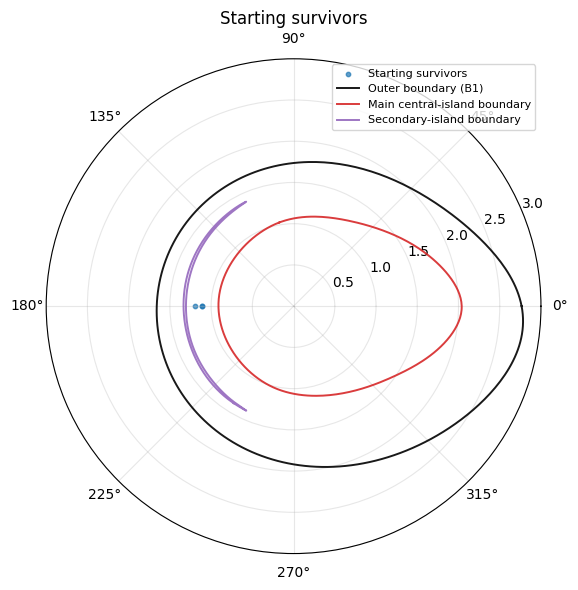

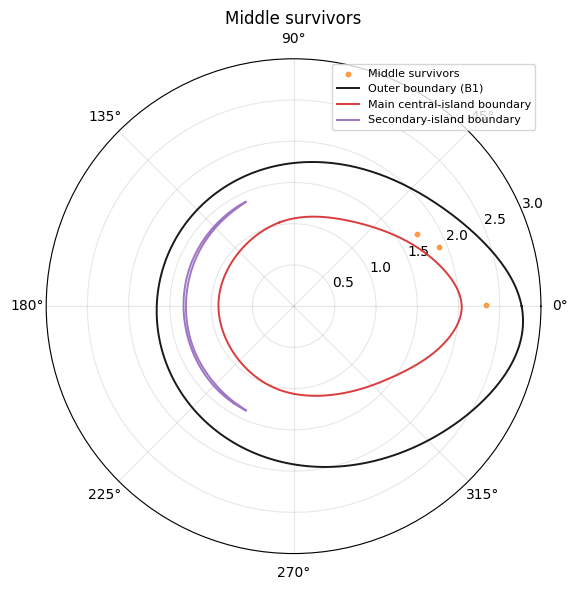

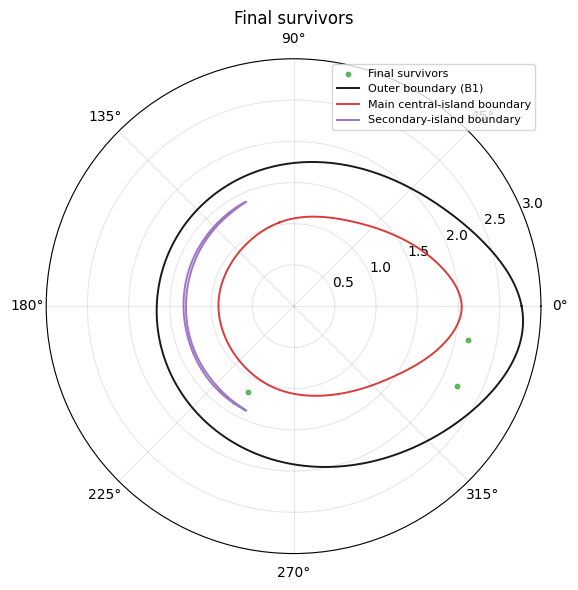

In [70]:
from src.utils.plotting import save_figure
fig_start, _ = plot_sprinkler_points(starting_points, stage='start')
fig_middle, _ = plot_sprinkler_points(middle_points, stage='middle')
fig_final, _ = plot_sprinkler_points(final_points, stage='final')

# save_figure(fig = fig_start, name='sprinkler_start_high_precision1.png', folder_path='plots')
# save_figure(fig = fig_middle, name='sprinkler_middle_high_precision1.png', folder_path='plots')
# save_figure(fig = fig_final, name='sprinkler_final_high_precision1.png', folder_path='plots')


In [71]:
print("Surviving points: ", starting_points['v'], starting_points['t'])

Surviving points:  [1.1082766  1.10472699 1.19606478] [3.14159265 3.14159265 3.14159265]


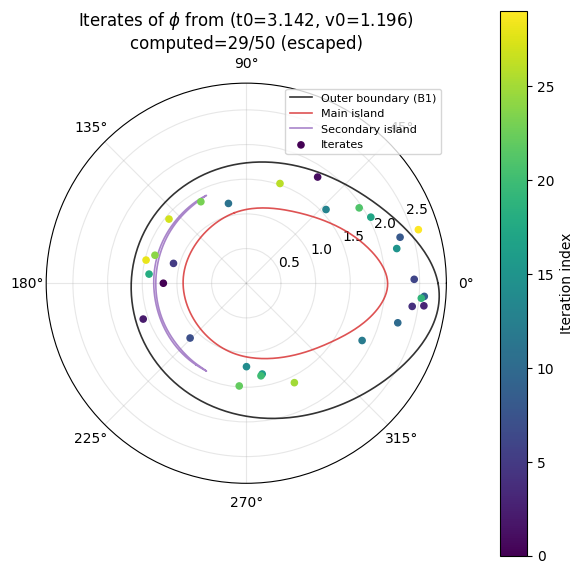

In [74]:
idx = 2
fig_iter, _ = plot_phi_iterates(starting_points['v'][idx], starting_points['t'][idx], n_steps=N_STEPS, rtol=1e-7, atol=1e-10)